In [2]:
import sys

#from script_tmp.watch_9WORKING2_mod import index_right, controls

sys.path.append("../")
import math
import copy
import pickle

import torch
import json
import matplotlib.pyplot as plt

import imodal
device = 'cpu'
imodal.Utilities.set_compute_backend('torch')

[KeOps] Warning : Cuda libraries were not detected on the system or could not be loaded ; using cpu only mode


In [3]:
col_source = 'dodgerblue'
col_target = 'limegreen'
col_grid = 'black'
alpha_grid = 0.2

(0.35538601577281953,
 0.7782810360193253,
 -0.4371690347790718,
 0.6628309980034828)

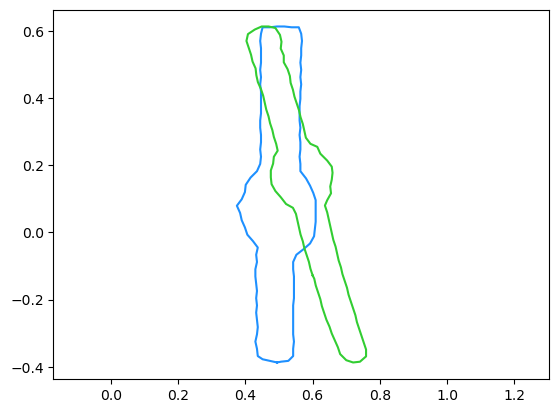

In [4]:
path_data = '../data/'
target_points = torch.load(path_data + 'watch_target.pt')
source_points = torch.load(path_data + 'watch_source.pt')


plt.figure()
plt.plot(source_points[:,0], source_points[:,1], '-', color=col_source)
plt.plot(target_points[:,0], target_points[:,1], '-', color=col_target)
plt.axis('equal')

(0.34555852860212327,
 0.642558540403843,
 -0.4371690347790718,
 0.6628309980034828)

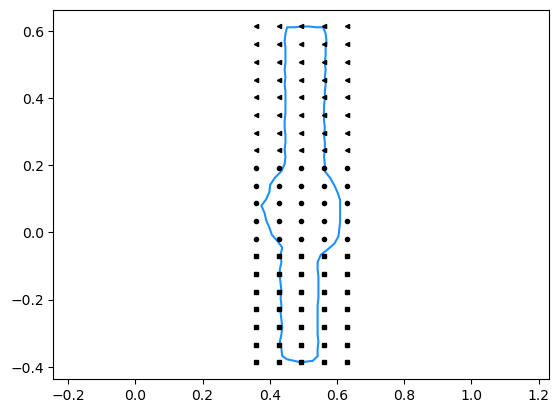

In [5]:
# load control points and segmentation in 3 components
pts_imp = torch.load(path_data + 'watch_CP.pt')
index_top = torch.load(path_data + 'watch_index_top.pt')
index_mid = torch.load(path_data + 'watch_index_mid.pt')
index_bot = torch.load(path_data + 'watch_index_left.pt')
plt.figure()
ax = plt.subplot()
plt.plot(source_points[:, 0].numpy(), source_points[:, 1].numpy(), color=col_source)
plt.plot(pts_imp[index_bot,0], pts_imp[index_bot,1], 's', color=col_grid, markersize=3)
plt.plot(pts_imp[index_top,0], pts_imp[index_top,1], '<', color=col_grid, markersize=3)
plt.plot(pts_imp[index_mid,0], pts_imp[index_mid,1], 'o', color=col_grid, markersize=3)
plt.axis('equal')

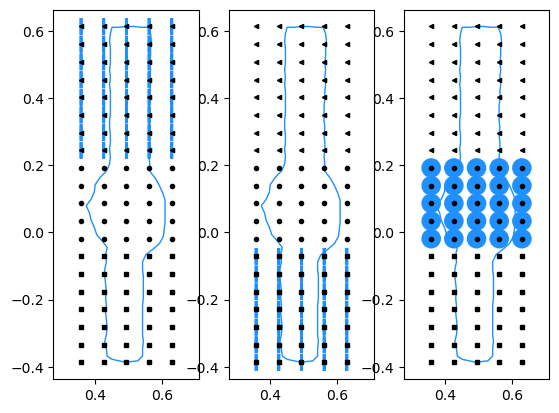

In [23]:
# Define and plot growth model operator via the tensor C
N = pts_imp.shape[0]
C = torch.zeros(N, 2, 3)
C[index_top, 1, 0] = 1 # first component of control corresponds to a vertical elongation of the top strap
C[index_bot, 1, 1] = 1 # second component of control corresponds to a vertical elongation of the bottom strap
C[index_mid, :, 2] = 1 # third component of control corresponds to a isotrop scaling of the case


rot_growth = torch.stack([imodal.Utilities.rot2d(0.)]*N, axis=0) # initial frames set to Identity

for i in range(C.shape[2]):
    ax = plt.subplot(1,3,i+1)
    plt.plot(source_points[:, 0].numpy(), source_points[:, 1].numpy(), color=col_source, lw=1)
    plt.plot(pts_imp[index_bot,0], pts_imp[index_bot,1], 's', color=col_grid, markersize=3)
    plt.plot(pts_imp[index_top,0], pts_imp[index_top,1], '<', color=col_grid, markersize=3)
    plt.plot(pts_imp[index_mid,0], pts_imp[index_mid,1], 'o', color=col_grid, markersize=3)
    imodal.Utilities.plot_C_ellipses(ax, pts_imp, C[:,:,i].unsqueeze(-1),
                                    R=rot_growth, color=col_source, scale=0.05,
                                    zorder=1, alpha=1, lw=2)



    plt.axis('equal')
plt.show()


In [7]:
# module definition
nu = 1e-4* N
coeff_growth = 0.01
scale_growth = 0.15

df = imodal.DeformationModules.ImplicitModule1(2, N,
                                                   scale_growth, C,
                                                   coeff=coeff_growth,
                                                   nu=nu,
                                                   gd=(pts_imp, rot_growth)
                                                  )

In [8]:
# addition of global rotation and translation
rotation = imodal.DeformationModules.LocalRotation(2, 1.5)
point_rotation = torch.tensor([[0.45, 0.1]])
rotation.manifold.fill_gd(point_rotation)

global_translation = imodal.DeformationModules.GlobalTranslation(2, coeff=2.)


In [9]:
deformable_shape_source = imodal.Models.DeformablePoints(source_points.contiguous())
deformable_shape_target = imodal.Models.DeformablePoints(target_points)
deformable_shape_source.to_device(device)

In [10]:
# Definition of deformation model
model = imodal.Models.RegistrationModel([deformable_shape_source],
                [global_translation, df, rotation],
                [imodal.Attachment.VarifoldAttachment(2, [0.5 , 0.05], backend='torch')],
                lam=5000.)

In [11]:
# Fitting
shoot_solver = 'euler'
shoot_it = 10

costs = {}
fitter = imodal.Models.Fitter(model, optimizer='torch_lbfgs')
fitter.fit([deformable_shape_target], 50, costs=costs, options={'shoot_solver': shoot_solver, 'shoot_it': shoot_it, 'line_search_fn': 'strong_wolfe', 'max_iter':1,  'max_eval':1})

Starting optimization with method torch LBFGS, using solver euler with 10 iterations.
Initial cost={'deformation': 0.0, 'attach': 3717.4599609375}
1e-10
Evaluated model with costs=3717.4599609375
Evaluated model with costs=6696.836136579514
Evaluated model with costs=2994.0529029145837
Time: 2.738468900999578
Iteration: 0
Costs
deformation=0.09050057083368301
attach=2993.96240234375
Total cost=2994.0529029145837
1e-10
Evaluated model with costs=2994.0529029145837
Evaluated model with costs=2691.5314346402884
Evaluated model with costs=1830.7587721347809
Time: 5.4162678969996705
Iteration: 1
Costs
deformation=0.9275953769683838
attach=1829.8311767578125
Total cost=1830.7587721347809
1e-10
Evaluated model with costs=1830.7587721347809
Evaluated model with costs=653.2904794216156
Time: 7.192684869000004
Iteration: 2
Costs
deformation=1.6442391872406006
attach=651.646240234375
Total cost=653.2904794216156
1e-10
Evaluated model with costs=653.2904794216156
Evaluated model with costs=529.768

{'c1': [], 'c2': [], 'c3': []}

In [12]:
# Computing estimated deformation
intermediates = {}
with torch.autograd.no_grad():
    deformed = model.compute_deformed(shoot_solver, shoot_it, intermediates=intermediates)


In [13]:
# Recomputing deformation with the deformation of a grid for vizualization purpose

modules = imodal.DeformationModules.CompoundModule(copy.copy(model.modules))
modules.manifold.fill(model.init_manifold)

square_size = 0.05

aabb_source = imodal.Utilities.AABB.build_from_points(source_points)
grid_resolution = [math.floor(aabb_source.width/square_size), 5]

deformation_grid = imodal.DeformationModules.DeformationGrid(aabb_source, grid_resolution)

controls = [control[1:] for control in intermediates['controls']]

deformable_shape = imodal.Models.DeformablePoints(source_points)
deformable_shape.silent_module.manifold.cotan = model.init_manifold[0].cotan
deformable_grid = imodal.Models.DeformableGrid(aabb_source, grid_resolution)

intermediates_grid = {}
with torch.autograd.no_grad():
    imodal.Models.deformables_compute_deformed([deformable_shape, deformable_grid], modules[1:], shoot_solver, shoot_it, intermediates=intermediates_grid, controls=controls)

/home/gris/miniconda3/envs/envimodal/lib/python3.11/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


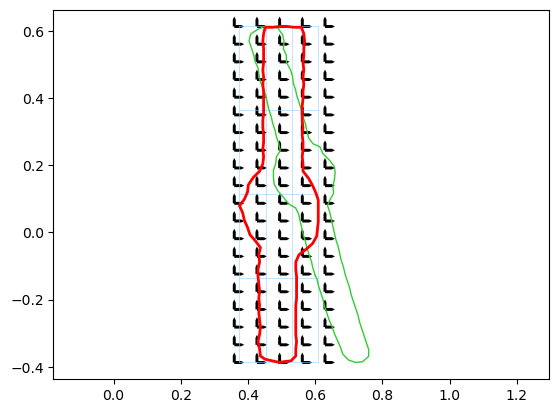

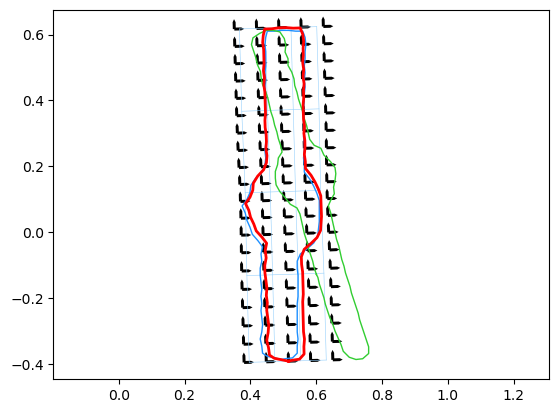

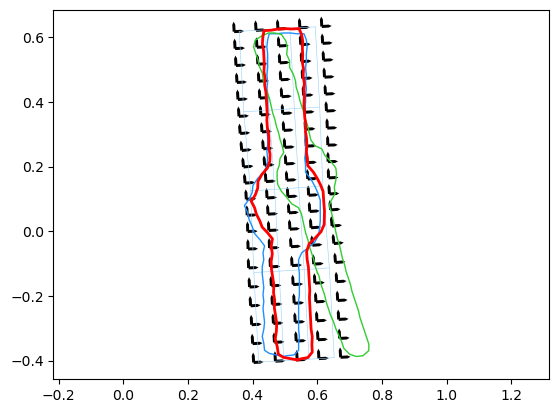

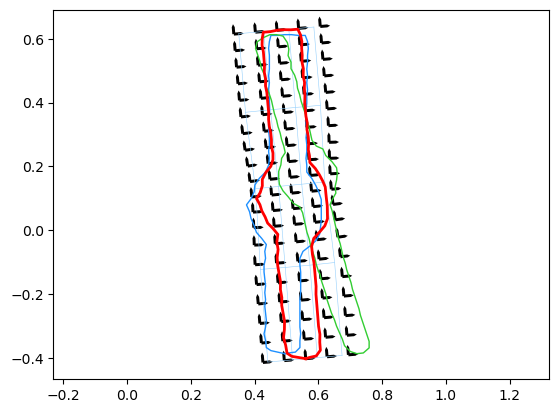

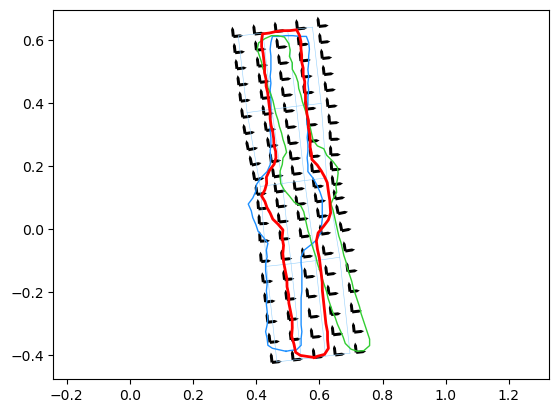

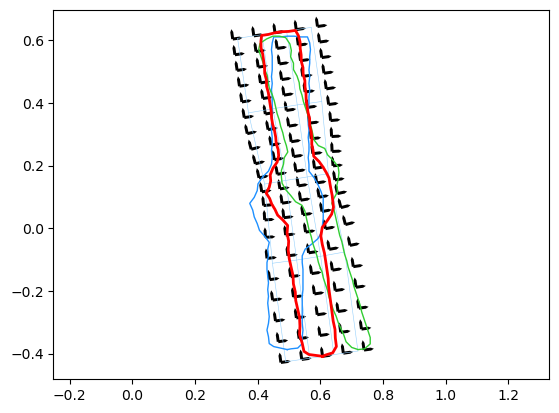

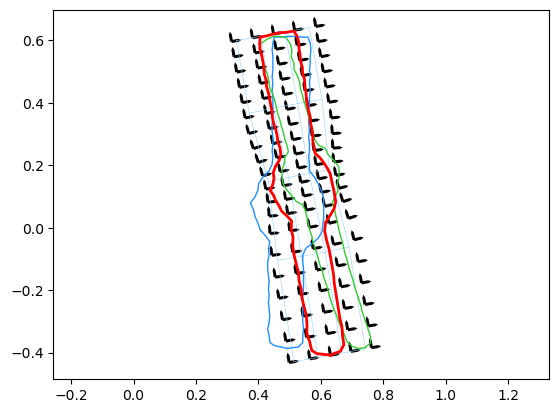

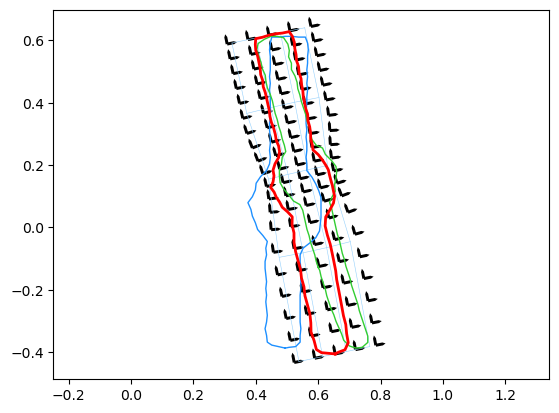

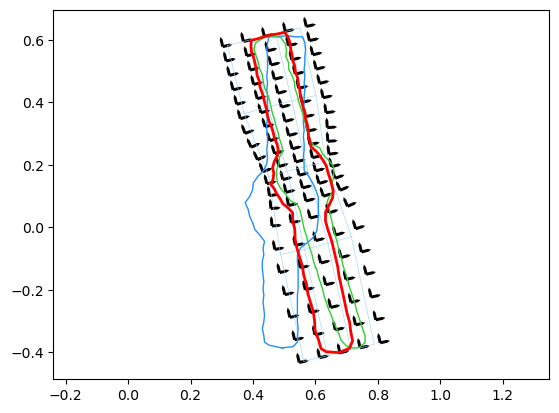

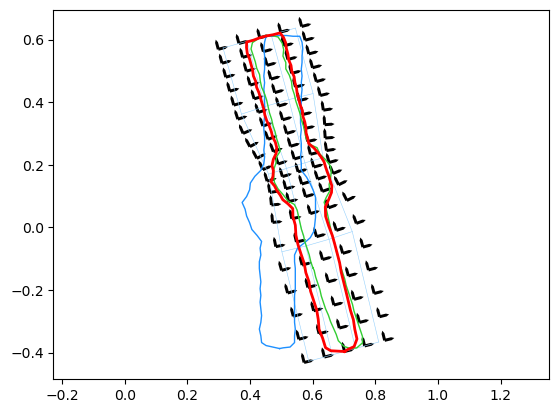

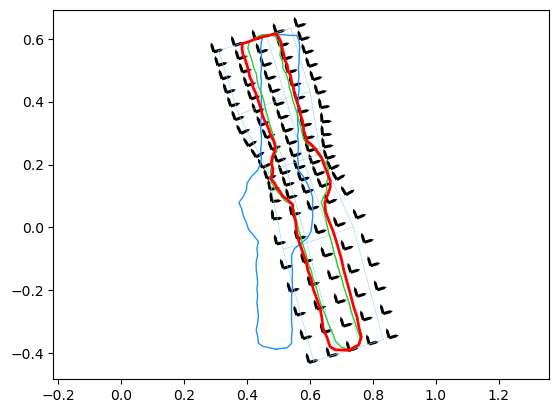

In [17]:
# Plotting estimated shape deformation and deformed frames

tar = deformable_shape_target.geometry[0]
for i in range(shoot_it + 1):
    plt.figure()
    ax = plt.subplot()
    state = intermediates_grid['states'][i]

    ax = plt.subplot()
    deformable_grid.silent_module.manifold.fill_gd(state[1].gd)
    grid_x, grid_y = deformable_grid.silent_module.togrid()
    imodal.Utilities.plot_grid(ax, grid_x, grid_y, color='xkcd:light blue', lw=0.4)

    plt.plot(source_points[:, 0].numpy(), source_points[:, 1].numpy(), color=col_source, lw=1)
    plt.plot(tar[:, 0].numpy(), tar[:, 1].numpy(), color=col_target, lw=1)
    plt.plot(state[0].gd[:, 0].numpy(), state[0].gd[:, 1].numpy(), color='red', lw=2)
    plt.quiver(state[3].gd[0][:, 0].numpy(), state[3].gd[0][:, 1].numpy(), state[3].gd[1][:, 0, 0].numpy(), state[3].gd[1][:, 1, 0].numpy(), lw=0.1, scale = 50., headlength=1, headwidth=1)
    plt.quiver(state[3].gd[0][:, 0].numpy(), state[3].gd[0][:, 1].numpy(), state[3].gd[1][:, 0, 1].numpy(), state[3].gd[1][:, 1, 1].numpy(), lw=0.1, scale = 50., headlength=1, headwidth=1)
    plt.axis('equal')
